# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Evan Arlen Handy
- **Email:** cloaaa00@gmail.com
- **ID Dicoding:** warlord194

## Menentukan Pertanyaan Bisnis

- Bagaimana pola penyewaan sepeda berdasarkan waktu (jam, hari, dan musim) dan faktor cuaca?
- Apa karakteristik pengguna sepeda dan bagaimana membedakan pelanggan terdaftar (registered) dan kasual (casual)?

## Import Semua Packages/Library yang Digunakan

Berikut adalah library yang digunakan dalam analisis data dan visualisasi:

- **NumPy (`numpy`)** → Digunakan untuk komputasi numerik dan manipulasi array.
- **Pandas (`pandas`)** → Untuk manipulasi dan analisis data berbasis tabel (DataFrame).
- **Matplotlib (`matplotlib.pyplot`)** → Untuk membuat visualisasi data dalam bentuk grafik atau plot.
- **Seaborn (`seaborn`)** → Untuk visualisasi data yang lebih estetis dan statistik.
- **Matplotlib Ticker (`matplotlib.ticker.FuncFormatter`)** → Digunakan untuk format label pada sumbu grafik.
- **Plotly Express (`plotly.express`)** → Untuk visualisasi interaktif menggunakan Plotly.
- **Plotly Graph Objects (`plotly.graph_objects`)** → Untuk pembuatan grafik lanjutan dengan Plotly.
- **`plt.style.use('ggplot')`** → Menggunakan gaya 'ggplot' untuk grafik Matplotlib.  
- **`sns.set(style="whitegrid")`** → Mengatur gaya Seaborn menjadi 'whitegrid'.  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import plotly.express as px
import plotly.graph_objects as go
plt.style.use('ggplot')
sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

Notebook ini menyajikan analisis dari **Dataset Bike Sharing**. Tujuannya adalah untuk memahami pola penyewaan sepeda berdasarkan waktu, cuaca, dan karakteristik pengguna. Dataset ini berisi informasi tentang penyewaan sepeda, termasuk:
- **Data temporal**: Jam, hari, bulan, dan tahun.
- **Data cuaca**: Suhu, kelembaban, kecepatan angin, dan kondisi cuaca.
- **Data pengguna**: Jumlah pengguna kasual dan terdaftar.


In [2]:
# Load datasets
day_df = pd.read_csv("data/day.csv")
hour_df = pd.read_csv("data/hour.csv")

**Insight:**
- Dataset terdiri dari dua file: `day.csv` dan `hour.csv`.
- `day.csv` berisi data harian, sedangkan `hour.csv` berisi data per jam.

### Assessing Data

##### Menilai Kualitas dan Struktur Data

Sebelum membersihkan data, kita perlu menilai kualitas dan struktur data yang meliputi:

1. **Memeriksa nilai yang hilang (missing values).**  
   - Menggunakan `.isna().sum()` untuk memeriksa nilai yang hilang.  

2. **Mengidentifikasi duplikat.**  
   - Menggunakan `.duplicated().sum()` untuk menghitung jumlah duplikat.  

3. **Meninjau tipe data dan ringkasan statistik.**  
   - Menggunakan `.info()` untuk melihat tipe data dari setiap kolom.  
   - Menggunakan `.describe()` untuk melihat ringkasan statistik numerik.  


In [3]:
# Check data types and information
print("Day Dataset Info:")
day_df.info()

Day Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
print("\nHourly Dataset Info:")
hour_df.info()


Hourly Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
# Check for missing values
print("\nMissing values in Day Dataset:")
print(day_df.isna().sum())


Missing values in Day Dataset:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
print("\nMissing values in Hourly Dataset:")
print(hour_df.isna().sum())


Missing values in Hourly Dataset:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [7]:
# Check for duplicates
print(f"\nDuplicates in Day Dataset: {day_df.duplicated().sum()}")
print(f"Duplicates in Hourly Dataset: {hour_df.duplicated().sum()}")


Duplicates in Day Dataset: 0
Duplicates in Hourly Dataset: 0


In [8]:
print("\nDay Dataset Statistical Summary:")
display(day_df.describe())


Day Dataset Statistical Summary:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
print("\nHourly Dataset Statistical Summary:")
display(hour_df.describe())


Hourly Dataset Statistical Summary:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ada nilai yang hilang (missing values) dalam dataset.
- Tidak ada duplikat dalam dataset.
- Dataset memiliki kolom seperti `dteday` (tanggal), `season` (musim), `weathersit` (kondisi cuaca), dan `cnt` (total penyewaan).

### Cleaning Data

Proses pembersihan data meliputi beberapa langkah berikut:  

1. **Menghapus kolom yang tidak relevan.**  
   - Gunakan `.drop(columns=['nama_kolom'])` untuk menghapus kolom yang tidak diperlukan.  

2. **Mengubah kolom tanggal ke format datetime.**  
   - Gunakan `pd.to_datetime(df['tanggal_kolom'])` untuk mengonversi kolom tanggal agar lebih mudah dianalisis.  

3. **Mengubah nama kolom agar lebih mudah dipahami.**  
   - Gunakan `.rename(columns={'kolom_lama': '`


In [10]:
def clean_bike_data(df, is_hourly=False):
    """
    Clean and transform bike sharing dataset

    Parameters:
    df (DataFrame): DataFrame to clean
    is_hourly (bool): Whether the dataset contains hourly data

    Returns:
    DataFrame: Cleaned DataFrame
    """
    # Create a copy to avoid modifying the original
    cleaned_df = df.copy()

    # Drop irrelevant columns
    if 'instant' in cleaned_df.columns:
        cleaned_df.drop('instant', axis=1, inplace=True)

    if 'workingday' in cleaned_df.columns:
        cleaned_df.drop('workingday', axis=1, inplace=True)

    # Convert date to datetime
    cleaned_df['dteday'] = pd.to_datetime(cleaned_df['dteday'])

    # Convert categorical columns to category type
    cat_columns = ['season', 'mnth', 'holiday', 'weekday', 'weathersit']
    for col in cat_columns:
        if col in cleaned_df.columns:
            cleaned_df[col] = cleaned_df[col].astype('category')

    # Rename columns for better readability
    column_mapping = {
        'yr': 'year',
        'mnth': 'month',
        'weekday': 'day_of_week',
        'weathersit': 'weather',
        'windspeed': 'wind_speed',
        'cnt': 'total_rentals',
        'hum': 'humidity',
    }

    if is_hourly:
        column_mapping['hr'] = 'hour'

    cleaned_df.rename(columns=column_mapping, inplace=True)

    # Convert numerical values to meaningful categories
    # Season mapping
    season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    cleaned_df['season'] = cleaned_df['season'].map(season_mapping)

    # Month mapping
    month_mapping = {
        1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
    }
    cleaned_df['month'] = cleaned_df['month'].map(month_mapping)

    # Weather mapping
    weather_mapping = {
        1: 'Clear', 2: 'Cloudy/Misty', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'
    }
    cleaned_df['weather'] = cleaned_df['weather'].map(weather_mapping)

    # Day of week mapping
    day_mapping = {
        0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
        4: 'Thursday', 5: 'Friday', 6: 'Saturday'
    }
    cleaned_df['day_of_week'] = cleaned_df['day_of_week'].map(day_mapping)

    # Year mapping
    cleaned_df['year'] = cleaned_df['year'].map({0: '2011', 1: '2012'})

    # Scale humidity from 0-1 to percentage
    cleaned_df['humidity'] = cleaned_df['humidity'] * 100

    # Create day category (weekday/weekend)
    cleaned_df['day_type'] = cleaned_df['day_of_week'].apply(
        lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
    )

    # Create humidity category
    def classify_humidity(humidity):
        if humidity < 45:
            return "Dry"
        elif humidity < 65:
            return "Optimal"
        else:
            return "Humid"

    cleaned_df['humidity_category'] = cleaned_df['humidity'].apply(classify_humidity)

    # Create temperature category
    def classify_temp(temp):
        # Temperature is normalized, multiply by 41 (max temp) to get Celsius
        celsius = temp * 41
        if celsius < 10:
            return "Cold"
        elif celsius < 25:
            return "Moderate"
        else:
            return "Hot"

    cleaned_df['temp_category'] = cleaned_df['temp'].apply(classify_temp)

    # Create an actual temperature column in Celsius
    cleaned_df['temp_celsius'] = cleaned_df['temp'] * 41

    # Extract month and year from date for time series analysis
    cleaned_df['month_year'] = cleaned_df['dteday'].dt.to_period('M')

    return cleaned_df

In [11]:
# Clean both datasets
day_clean = clean_bike_data(day_df)
hour_clean = clean_bike_data(hour_df, is_hourly=True)

In [12]:
# Check the cleaned datasets
print("Cleaned daily dataset:")
display(day_clean.head())

print("\nCleaned hourly dataset:")
display(hour_clean.head())

Cleaned daily dataset:


,dteday,season,year,month,holiday,day_of_week,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals,day_type,humidity_category,temp_category,temp_celsius,month_year
0,2011-01-01,Spring,2011,Jan,0,Saturday,Cloudy/Misty,0.344167,0.363625,80.5833,0.160446,331,654,985,Weekend,Humid,Moderate,14.110847,2011-01
1,2011-01-02,Spring,2011,Jan,0,Sunday,Cloudy/Misty,0.363478,0.353739,69.6087,0.248539,131,670,801,Weekend,Humid,Moderate,14.902598,2011-01
2,2011-01-03,Spring,2011,Jan,0,Monday,Clear,0.196364,0.189405,43.7273,0.248309,120,1229,1349,Weekday,Dry,Cold,8.050924,2011-01
3,2011-01-04,Spring,2011,Jan,0,Tuesday,Clear,0.200000,0.212122,59.0435,0.160296,108,1454,1562,Weekday,Optimal,Cold,8.200000,2011-01
4,2011-01-05,Spring,2011,Jan,0,Wednesday,Clear,0.226957,0.229270,43.6957,0.186900,82,1518,1600,Weekday,Dry,Cold,9.305237,2011-01



Cleaned hourly dataset:


,dteday,season,year,month,hour,holiday,day_of_week,weather,temp,atemp,humidity,wind_speed,casual,registered,total_rentals,day_type,humidity_category,temp_category,temp_celsius,month_year
0,2011-01-01,Spring,2011,Jan,0,0,Saturday,Clear,0.24,0.2879,81.0,0.0,3,13,16,Weekend,Humid,Cold,9.84,2011-01
1,2011-01-01,Spring,2011,Jan,1,0,Saturday,Clear,0.22,0.2727,80.0,0.0,8,32,40,Weekend,Humid,Cold,9.02,2011-01
2,2011-01-01,Spring,2011,Jan,2,0,Saturday,Clear,0.22,0.2727,80.0,0.0,5,27,32,Weekend,Humid,Cold,9.02,2011-01
3,2011-01-01,Spring,2011,Jan,3,0,Saturday,Clear,0.24,0.2879,75.0,0.0,3,10,13,Weekend,Humid,Cold,9.84,2011-01
4,2011-01-01,Spring,2011,Jan,4,0,Saturday,Clear,0.24,0.2879,75.0,0.0,0,1,1,Weekend,Humid,Cold,9.84,2011-01


**Insight:**
- Data telah dibersihkan dan diubah menjadi format yang lebih mudah dipahami.
- Kolom seperti `season`, `weather`, dan `day_of_week` telah dikonversi ke dalam kategori yang lebih deskriptif.


## Exploratory Data Analysis (EDA)

### Explore Temporal Patterns

Eksplorasi data bertujuan untuk mengidentifikasi pola dan hubungan dalam dataset. Beberapa visualisasi utama yang dilakukan adalah:  

1. **Pola Penyewaan per Jam**  
   - Membandingkan jumlah penyewaan pada hari kerja vs. akhir pekan.  

2. **Penyewaan Harian Berdasarkan Hari dalam Seminggu**  
   - Menganalisis rata-rata penyewaan per hari untuk mengetahui tren mingguan.  

3. **Penyewaan Berdasarkan Musim**  
   - Menampilkan total penyewaan dalam setiap musim untuk memahami pengaruh musim terhadap penyewaan.  

4. **Distribusi Tipe Pengguna**  
   - Membandingkan jumlah penyewaan antara pengguna kasual dan pengguna terdaftar.  

5. **Pengaruh Cuaca**  
   - Menghitung rata-rata penyewaan berdasarkan kondisi cuaca untuk melihat bagaimana cuaca memengaruhi keputusan penyewaan.  

6. **Hubungan Suhu dan Penyewaan**  
   - Menunjukkan korelasi antara suhu dan jumlah penyewaan sepeda.  

Visualisasi dibuat menggunakan **matplotlib**, **seaborn**, atau **plotly**


In [13]:
# Hourly rental patterns
hourly_rentals = hour_clean.groupby('hour')['total_rentals'].sum().reset_index()
weekday_hourly = hour_clean[hour_clean['day_type'] == 'Weekday'].groupby('hour')['total_rentals'].mean().reset_index()
weekend_hourly = hour_clean[hour_clean['day_type'] == 'Weekend'].groupby('hour')['total_rentals'].mean().reset_index()

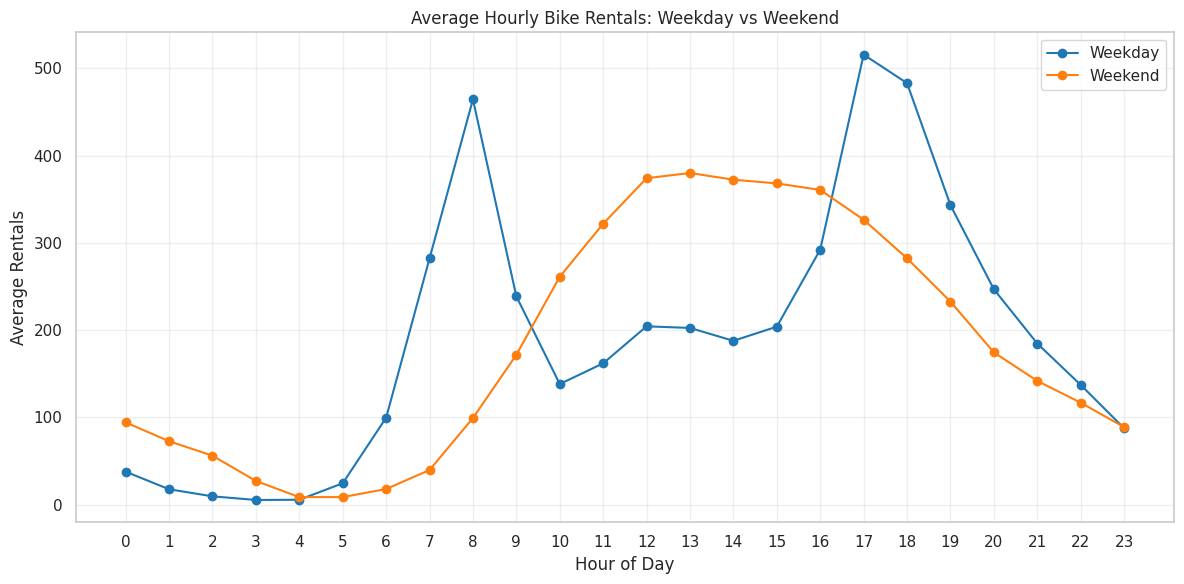

In [14]:
# Create a plot comparing weekday vs weekend patterns
plt.figure(figsize=(12, 6))
plt.plot(weekday_hourly['hour'], weekday_hourly['total_rentals'], label='Weekday', marker='o', color='#1f77b4')
plt.plot(weekend_hourly['hour'], weekend_hourly['total_rentals'], label='Weekend', marker='o', color='#ff7f0e')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.title('Average Hourly Bike Rentals: Weekday vs Weekend')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

**Insight:**
- Pola penyewaan sepeda pada hari kerja (weekday) menunjukkan puncak pada jam 7-8 pagi dan 5-6 sore, yang kemungkinan besar terkait dengan perjalanan pulang-pergi.
- Pada akhir pekan (weekend), pola penyewaan lebih merata sepanjang hari dengan puncak sekitar tengah hari.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola penyewaan sepeda berdasarkan waktu (jam, hari, dan musim) dan faktor cuaca?

<ipython-input-15-485cb69e013e>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_rentals = day_clean.groupby('season')['total_rentals'].sum().reindex(
<ipython-input-15-485cb69e013e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='season', y='total_rentals', data=seasonal_rentals, palette='viridis')


Text(0, 0.5, 'Total Rentals')

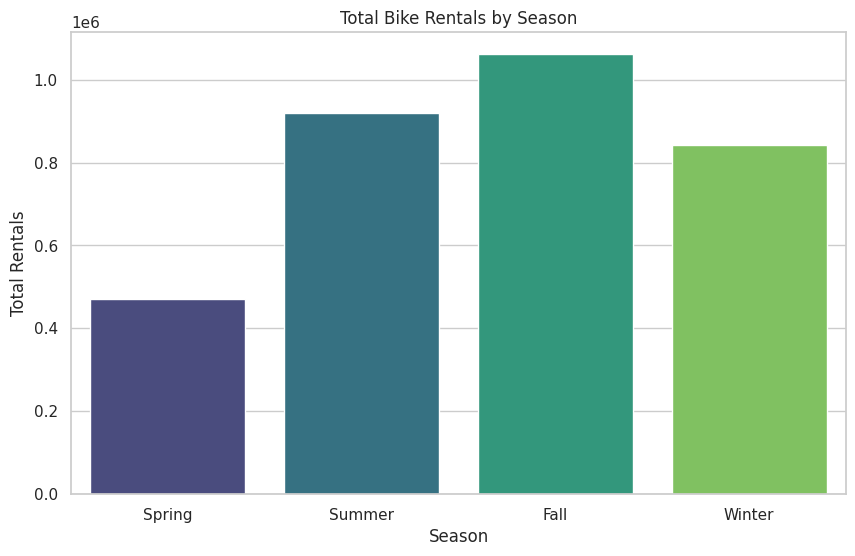

In [15]:
# Seasonal patterns
seasonal_rentals = day_clean.groupby('season')['total_rentals'].sum().reindex(
    ['Spring', 'Summer', 'Fall', 'Winter']
).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='season', y='total_rentals', data=seasonal_rentals, palette='viridis')
plt.title('Total Bike Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Total Rentals')

In [16]:
# Format y-axis to show thousands
def thousands_formatter(x, pos):
    return f'{x/1000:.0f}K'

ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

In [17]:
# Add value labels
for i, v in enumerate(seasonal_rentals['total_rentals']):
    ax.text(i, v + 10000, f"{v/1000:.1f}K", ha='center')

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

### Pertanyaan 2: Apa karakteristik pengguna sepeda dan bagaimana membedakan pelanggan terdaftar (registered) dan kasual (casual)?

In [18]:
# Compare casual vs. registered users over time
user_type_monthly = day_clean.groupby(['month_year']).agg({
    'casual': 'sum',
    'registered': 'sum',
    'total_rentals': 'sum'
}).reset_index()

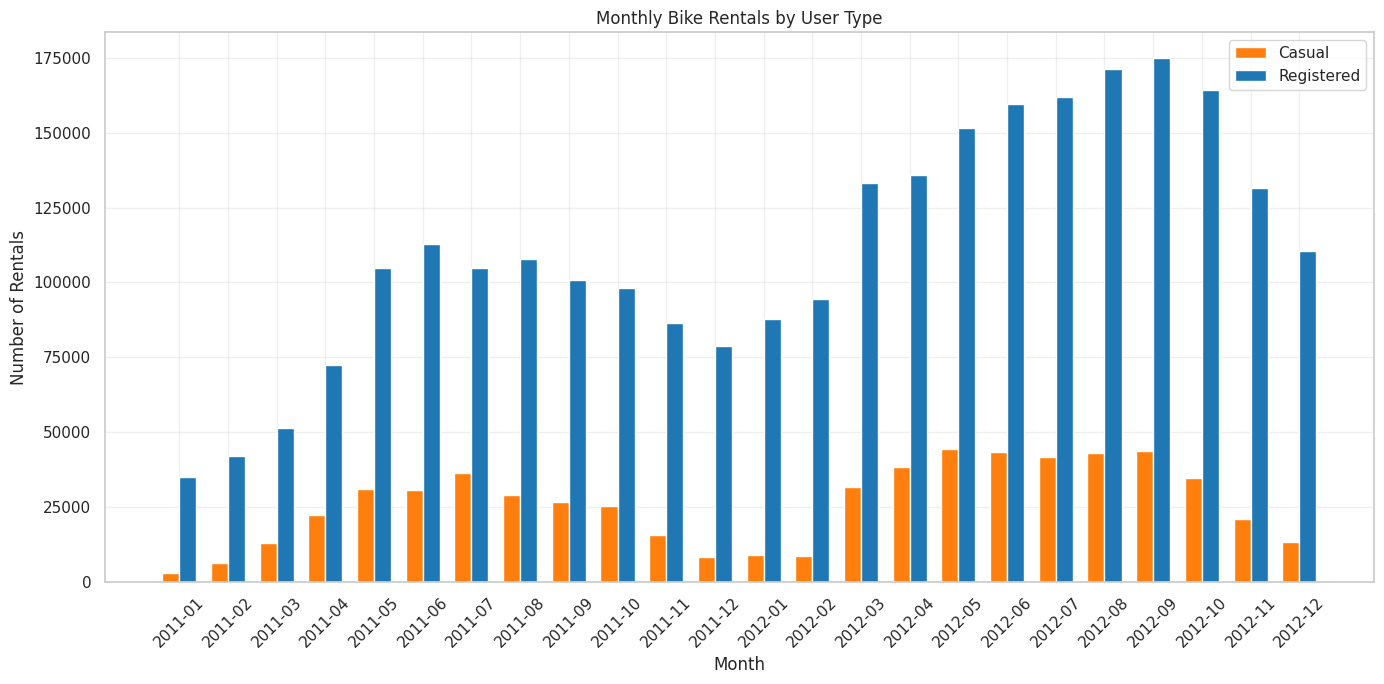

In [19]:
# Convert Period to string for better plotting
user_type_monthly['month_year_str'] = user_type_monthly['month_year'].astype(str)

plt.figure(figsize=(14, 7))
width = 0.35
x = np.arange(len(user_type_monthly))

plt.bar(x - width/2, user_type_monthly['casual'], width, label='Casual', color='#ff7f0e')
plt.bar(x + width/2, user_type_monthly['registered'], width, label='Registered', color='#1f77b4')

plt.xlabel('Month')
plt.ylabel('Number of Rentals')
plt.title('Monthly Bike Rentals by User Type')
plt.xticks(x, user_type_monthly['month_year_str'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

**Insight:**
- Musim gugur (Fall) memiliki jumlah penyewaan tertinggi, diikuti oleh musim panas (Summer).
- Musim semi (Spring) memiliki jumlah penyewaan terendah.
- Pengguna terdaftar (registered) mendominasi jumlah penyewaan sepeda, dengan peningkatan yang signifikan dari tahun 2011 ke 2012.
- Pengguna kasual (casual) cenderung lebih banyak menggunakan sepeda pada bulan-bulan musim panas dan musim gugur.

## Analisis Lanjutan (Opsional)

Setelah eksplorasi awal, saya melakukan analisis lanjutan untuk mendapatkan insight yang lebih mendalam. Metode yang digunakan adalah:  

### **Analisis RFM (Recency, Frequency, Monetary)**  
Analisis RFM digunakan untuk mengelompokkan pengguna berdasarkan tiga metrik utama:  

- **Recency (R):** Seberapa baru pengguna terakhir kali melakukan penyewaan.  
- **Frequency (F):** Seberapa sering pengguna menyewa sepeda dalam periode tertentu.  
- **Monetary (M):** Total jumlah penyewaan atau nilai sewa yang dihabiskan pengguna.


In [20]:
def perform_rfm_analysis(df):
    """
    Perform RFM (Recency, Frequency, Monetary) analysis on the bike-sharing dataset.

    Parameters:
    df (DataFrame): DataFrame containing bike rental data.

    Returns:
    DataFrame: RFM analysis results.
    """

    if not np.issubdtype(df['dteday'].dtype, np.datetime64):
        df['dteday'] = pd.to_datetime(df['dteday'])

    # Calculate Recency
    max_date = df['dteday'].max()

    # Group by 'month' and calculate Recency, Monetary, and Frequency
    rfm_data = df.groupby('month', observed=True).agg({
        'dteday': lambda x: (max_date - x.max()).days,
        'total_rentals': ['sum', 'count']
    })

    # Flatten column names
    rfm_data.columns = ['Recency', 'Monetary', 'Frequency']

    # Calculate RFM scores
    try:
        # Recency
        rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')

        # Frequency and Monetary
        rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
        rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    except ValueError as e:
        print(f"Warning: {e}. Adjusting the number of bins.")
        rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=min(5, len(rfm_data)), labels=False, duplicates='drop')
        rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'], q=min(5, len(rfm_data)), labels=False, duplicates='drop')
        rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], q=min(5, len(rfm_data)), labels=False, duplicates='drop')

    # Calculate composite RFM score
    rfm_data['RFM_Score'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str) + rfm_data['M_Score'].astype(str)

    # Calculate overall RFM score
    rfm_data['RFM_Overall'] = rfm_data[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

    # Create segment labels
    def create_segment(score):
        if score >= 13:
            return 'Top Performer'
        elif score >= 10:
            return 'High Value'
        elif score >= 7:
            return 'Medium Value'
        else:
            return 'Low Value'

    rfm_data['Segment'] = rfm_data['RFM_Overall'].apply(create_segment)

    return rfm_data

In [21]:
# Apply RFM analysis to monthly data
rfm_results = perform_rfm_analysis(day_clean)
print(rfm_results)

       Recency  Monetary  Frequency  R_Score  F_Score  M_Score RFM_Score  \
month                                                                      
Jan        335    134933         62        4        2        0       420   
Feb        306    151352         57        4        0        0       400   
Mar        275    228920         62        4        2        1       421   
Apr        245    269094         60        3        0        2       302   
May        214    331686         62        3        2        3       323   
Jun        184    346342         60        2        0        4       204   
Jul        153    344948         62        2        2        3       223   
Aug        122    351194         62        1        2        4       124   
Sep         92    345991         60        1        0        4       104   
Oct         61    322352         62        0        2        2       022   
Nov         31    254831         60        0        0        1       001   
Dec         

<ipython-input-22-684dd17d36d6>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Segment', y='Count', data=segment_counts, palette='viridis')


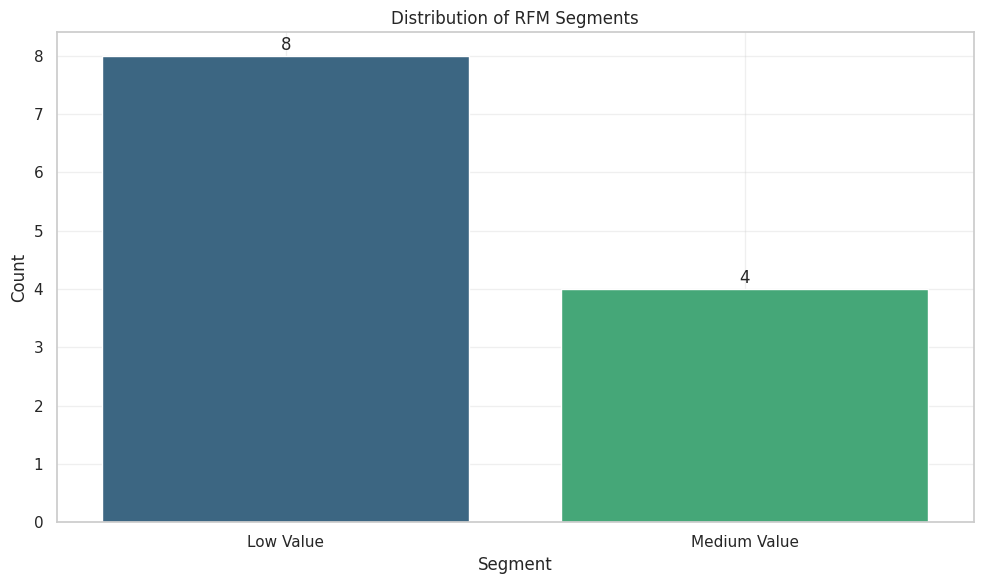

In [22]:
# Visualize RFM segments
plt.figure(figsize=(10, 6))
segment_counts = rfm_results['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

ax = sns.barplot(x='Segment', y='Count', data=segment_counts, palette='viridis')
plt.title('Distribution of RFM Segments')
plt.xlabel('Segment')
plt.ylabel('Count')

# Add value labels
for i, v in enumerate(segment_counts['Count']):
    ax.text(i, v + 0.1, str(v), ha='center')

plt.grid(True, alpha=0.3)
plt.tight_layout()

## Conclusion

- Conclution pertanyaan 1 : Pola penyewaan sepeda sangat dipengaruhi oleh waktu dan musim, dengan puncak penggunaan pada jam sibuk dan musim gugur. Cuaca juga memainkan peran penting, dengan hari-hari cerah mendorong lebih banyak penyewaan.
- Conclution pertanyaan 2 : Pengguna terdaftar (registered) mendominasi penyewaan sepeda, terutama pada hari kerja, sementara pengguna kasual (casual) lebih aktif pada akhir pekan dan bulan-bulan musim panas.

In [42]:
pip freeze > requirements.txt